# 1- Measures of Central Tendency

In [17]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Students Social Media Addiction.csv")

# Create random sample of size 150
ds = df.sample(n=150, random_state=42)
print(ds)

     Student_ID  Age  Gender Academic_Level      Country  \
478         479   20  Female  Undergraduate       France   
81           82   19  Female  Undergraduate   Azerbaijan   
77           78   22  Female       Graduate   Kyrgyzstan   
208         209   19  Female  Undergraduate   Bangladesh   
319         320   22    Male       Graduate      Germany   
..          ...  ...     ...            ...          ...   
424         425   19  Female  Undergraduate  Switzerland   
539         540   22    Male       Graduate       Canada   
110         111   20    Male  Undergraduate   Bangladesh   
82           83   20    Male  Undergraduate       Cyprus   
51           52   20  Female  Undergraduate     Paraguay   

     Avg_Daily_Usage_Hours Most_Used_Platform Affects_Academic_Performance  \
478                    3.0          Instagram                           No   
81                     4.8             TikTok                          Yes   
77                     2.9           Facebook

In [18]:
ds.mean(numeric_only=True) # find the average/mean of all numeric columns

Student_ID                     318.300000
Age                             20.600000
Avg_Daily_Usage_Hours            4.835333
Sleep_Hours_Per_Night            6.868667
Mental_Health_Score              6.226667
Conflicts_Over_Social_Media      2.833333
Addicted_Score                   6.393333
dtype: float64

In [19]:
mean_score = ds["Addicted_Score"].mean()   # find the average
print(f"Mean: {mean_score}")

Mean: 6.3933333333333335


In [20]:
ds.mean(axis=1, numeric_only=True)

478    75.000000
81     18.214286
77     17.700000
208    36.428571
319    52.357143
         ...    
424    67.114286
539    84.314286
110    22.900000
82     18.342857
51     14.071429
Length: 150, dtype: float64

In [21]:
ds.median(numeric_only=True) # find the median of numeric columns only

Student_ID                     296.00
Age                             20.00
Avg_Daily_Usage_Hours            4.80
Sleep_Hours_Per_Night            6.95
Mental_Health_Score              6.00
Conflicts_Over_Social_Media      3.00
Addicted_Score                   7.00
dtype: float64

In [22]:
median_score = ds["Addicted_Score"].median()   # find the median
print(f"Median: {median_score}")

Median: 7.0


In [23]:
mode_score = ds["Addicted_Score"].mode()[0]   # most repeated value
print(f"Mode: {mode_score}")

Mode: 7


# 2- Measures of Dispersion

In [24]:
# Minimum
min_score = ds["Addicted_Score"].min()
print(f"Minimum: {min_score}")

# Maximum
max_score = ds["Addicted_Score"].max()
print(f"Maximum: {max_score}")

# Range
score_range = ds["Addicted_Score"].max() - ds["Addicted_Score"].min()
print(f"Range: {score_range}")

# Standard Deviation
score_std = ds["Addicted_Score"].std()
print(f"Standard Deviation: {score_std}")

# Variance
score_var = ds["Addicted_Score"].var()
print(f"Variance: {score_var}")

Minimum: 2
Maximum: 9
Range: 7
Standard Deviation: 1.5881130023639392
Variance: 2.522102908277405


# 3- Measures of Position

In [25]:
# Skewness
score_skew = ds["Addicted_Score"].skew()   # skewness of addiction score
print(f"Skewness: {score_skew}")


Skewness: -0.250599241145306


In [26]:
# Kurtosis
score_kurt = ds["Addicted_Score"].kurt()   # kurtosis of addiction score
print(f"Kurtosis: {score_kurt}")

Kurtosis: -0.8438919858658651


In [27]:
five_num = [
    ds["Addicted_Score"].quantile(0),      # minimum
    ds["Addicted_Score"].quantile(0.25),   # Q1
    ds["Addicted_Score"].quantile(0.50),   # median (Q2)
    ds["Addicted_Score"].quantile(0.75),   # Q3
    ds["Addicted_Score"].quantile(1)       # maximum
]

five_num

[np.float64(2.0),
 np.float64(5.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0)]

In [28]:
score_iqr = ds["Addicted_Score"].quantile(0.75) - ds["Addicted_Score"].quantile(0.25)
print(f"IQR: {score_iqr}")

IQR: 3.0


In [29]:
def Desc_stat(ds, var):
    mean = ds[var].mean()
    median = ds[var].median()
    mode = ds[var].mode()[0]
    minimum = ds[var].min()
    maximum = ds[var].max()
    data_range = maximum - minimum
    std_dev = ds[var].std()
    variance = ds[var].var()
    skew = ds[var].skew()
    kurtosis = ds[var].kurt()
    count = ds[var].count()
    Quart = [
        ds[var].quantile(0),
        ds[var].quantile(0.25),
        ds[var].quantile(0.50),
        ds[var].quantile(0.75),
        ds[var].quantile(1),
        ds[var].quantile(0.75) - ds[var].quantile(0.25)
    ]
    summary = {
        "Mean": mean,
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": data_range,
        "Standard Deviation": std_dev,
        "Variance": variance,
        "Skewness": skew,
        "Kurtosis": kurtosis,
        "25th Percentile": Quart[1],
        "50th Percentile": Quart[2],
        "75th Percentile": Quart[3],
        "Interquartile Range (IQR)": Quart[5],
        "Count": count
    }
    return summary


# - Data Visualization

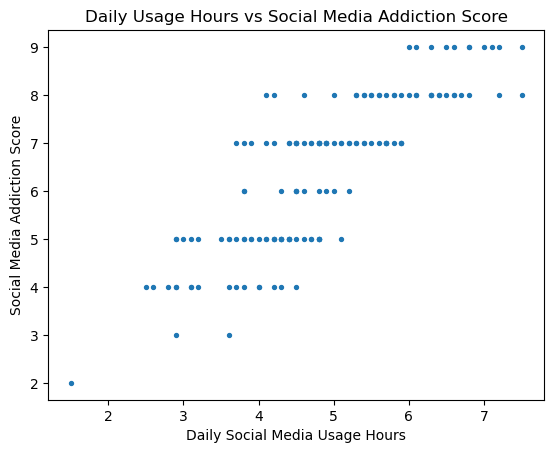

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# import dataset
df = pd.read_csv("Students Social Media Addiction.csv")

# generate random sample of 150
sample_size = 150
ds = df.sample(n=sample_size, replace=False, random_state=42)

# scatter plot
ds.plot.scatter(x="Avg_Daily_Usage_Hours", y="Addicted_Score", s=8)

plt.xlabel("Daily Social Media Usage Hours")
plt.ylabel("Social Media Addiction Score")
plt.title("Daily Usage Hours vs Social Media Addiction Score")

plt.show()

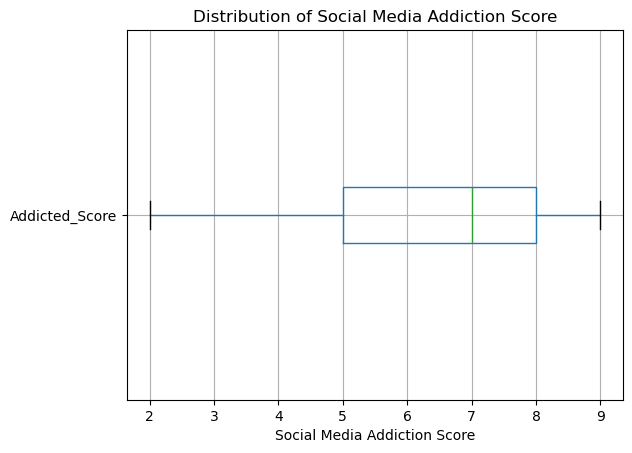

In [31]:
ax = ds.boxplot(column="Addicted_Score", vert=False)

ax.set_xlabel("Social Media Addiction Score")
ax.set_title("Distribution of Social Media Addiction Score")

plt.show()

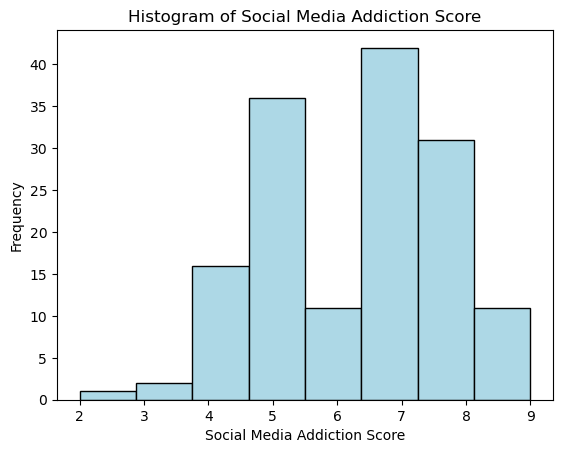

In [32]:
plt.hist(ds["Addicted_Score"], bins=8, edgecolor="black", color="lightblue")

plt.xlabel("Social Media Addiction Score")
plt.ylabel("Frequency")
plt.title("Histogram of Social Media Addiction Score")

plt.show()

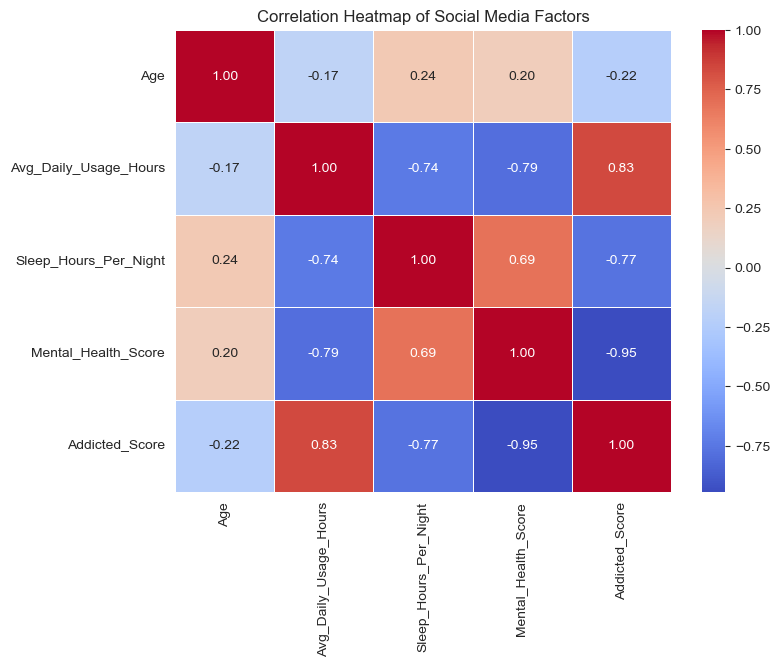

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = ds[["Age","Avg_Daily_Usage_Hours","Sleep_Hours_Per_Night","Mental_Health_Score","Addicted_Score"]].corr()
sns.set_style("white")
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,   # show correlation values
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Social Media Factors")
plt.show()

# - Pearson Correlation Coefficient

In [34]:
from scipy.stats import pearsonr

addiction_score = ds["Addicted_Score"].dropna()
daily_usage = ds["Avg_Daily_Usage_Hours"].dropna()

min_length = min(len(addiction_score), len(daily_usage))

addiction_score = addiction_score[:min_length]
daily_usage = daily_usage[:min_length]

r, p_value = pearsonr(addiction_score, daily_usage)

degree_of_freedom = len(addiction_score) - 2

print(f"Pearson's Correlation Coefficient r: {r:.3f}")
print(f"P-Value: {p_value:.3f}")
print(f"Degree of Freedom dof: {degree_of_freedom}")

if p_value < 0.05:
    print("\nConclusion: since the p-value is less than 0.05, we reject the null hypothesis")
    print("There is a significant correlation between social media usage hours and addiction score")
else:
    print("\nConclusion: since the p-value is more than 0.05, we accept the null hypothesis")
    print("There is no significant correlation between social media usage hours and addiction score")

Pearson's Correlation Coefficient r: 0.833
P-Value: 0.000
Degree of Freedom dof: 148

Conclusion: since the p-value is less than 0.05, we reject the null hypothesis
There is a significant correlation between social media usage hours and addiction score


# - Spearman Correlation Coefficient

In [35]:
from scipy.stats import spearmanr

ds_clean = ds[["Addicted_Score", "Avg_Daily_Usage_Hours"]].dropna()

rho_value, p_value = spearmanr(
    ds_clean["Addicted_Score"],
    ds_clean["Avg_Daily_Usage_Hours"]
)

print("Spearman's Correlation Test")
print(f"Spearman's Correlation Coefficient (ρ): {rho_value:.3f}")
print(f"P-Value (p): {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    print("\nConclusion: since the p-value is less than 0.05, we reject the null hypothesis")
    print("There is a statistically significant correlation between social media usage hours and addiction score")
else:
    print("\nConclusion: since the p-value is more than 0.05, we fail to reject the null hypothesis")
    print("There is no statistically significant correlation between social media usage hours and addiction score")

Spearman's Correlation Test
Spearman's Correlation Coefficient (ρ): 0.835
P-Value (p): 0.000

Conclusion: since the p-value is less than 0.05, we reject the null hypothesis
There is a statistically significant correlation between social media usage hours and addiction score


# - Chi-Square Test

In [36]:
from scipy.stats import chi2_contingency

contingency_data = pd.crosstab(ds["Gender"], ds["Conflicts_Over_Social_Media"])

chi2, p, dof, expected = chi2_contingency(contingency_data)

print(f"Chi-square value: {chi2:.3f}")
print(f"P-value: {p:.3f}")
print(f"Degree of Freedom: {dof}")

# Interpretation
if p > 0.05:
    print("Independent categories")
else:
    print("Dependent categories")

Chi-square value: 2.468
P-value: 0.781
Degree of Freedom: 5
Independent categories


# One-Sample T-Test

In [37]:
addicted_score = ds["Addicted_Score"].dropna()
print(addicted_score)
print()

average_addicted_score = ds["Addicted_Score"].mean()
print(f"Average addiction score: {average_addicted_score:.3f}")
print()

from scipy.stats import shapiro

# test Addicted_Score is normally distributed using Shapiro method
r, p = shapiro(ds["Addicted_Score"].dropna())
print(f"r: {r:.2f}, p:{p:.2f}")

if p > 0.05:
    print("Normal distribution")
else:
    print("Not a normal distribution")

# Null hypothesis -- average_addicted_score = 0
# Alternative hypothesis -- average_addicted_score != 0

# One Sample T-test
import scipy
_, p = scipy.stats.ttest_1samp(ds["Addicted_Score"].dropna(), 0)

if p > 0.05:
    print(f"Conclusion: since the p-value ({p}) is greater than 0.05, we accept the null hypothesis")
    print("The average addiction score is not significantly different from 0")
else:
    print(f"Conclusion: since the p-value ({p}) is less than 0.05, we reject the null hypothesis")
    print("The average addiction score is significantly different from 0")

478    5
81     7
77     5
208    7
319    4
      ..
424    4
539    6
110    8
82     6
51     7
Name: Addicted_Score, Length: 150, dtype: int64

Average addiction score: 6.393

r: 0.92, p:0.00
Not a normal distribution
Conclusion: since the p-value (3.666023819728956e-94) is less than 0.05, we reject the null hypothesis
The average addiction score is significantly different from 0


In [38]:
ds["Addicted_Score"].describe()

count    150.000000
mean       6.393333
std        1.588113
min        2.000000
25%        5.000000
50%        7.000000
75%        8.000000
max        9.000000
Name: Addicted_Score, dtype: float64

In [39]:
# Systematic Sampling
# Define sample size
n = 150
# Calculate step size
k = len(df) // n
# Select every k-th record
ds_sys = df.iloc[::k]
# Keep only first 150 observations
ds_sys = ds_sys.head(150)
# Apply descriptive statistics function
Desc_stat(ds_sys, "Addicted_Score")

{'Mean': np.float64(6.293333333333333),
 'Median': 7.0,
 'Mode': np.int64(7),
 'Minimum': 3,
 'Maximum': 9,
 'Range': 6,
 'Standard Deviation': 1.9543332224876633,
 'Variance': 3.8194183445190144,
 'Skewness': np.float64(-0.2010154733194439),
 'Kurtosis': np.float64(-1.225034550215906),
 '25th Percentile': np.float64(5.0),
 '50th Percentile': np.float64(7.0),
 '75th Percentile': np.float64(8.0),
 'Interquartile Range (IQR)': np.float64(3.0),
 'Count': np.int64(150)}

In [40]:
# Random Sampling
# Select a random sample of 150 records from the dataset

sample = df.sample(n=150, random_state=1)

# Display the sampled data
print(sample)

     Student_ID  Age  Gender Academic_Level      Country  \
404         405   19  Female  Undergraduate  Switzerland   
547         548   22    Male       Graduate       Poland   
333         334   21    Male       Graduate        India   
341         342   21    Male       Graduate      Denmark   
187         188   22    Male       Graduate     Pakistan   
..          ...  ...     ...            ...          ...   
647         648   23    Male       Graduate       Canada   
395         396   22    Male       Graduate       Turkey   
358         359   20  Female  Undergraduate       France   
45           46   23  Female       Graduate        Chile   
161         162   21    Male       Graduate        India   

     Avg_Daily_Usage_Hours Most_Used_Platform Affects_Academic_Performance  \
404                    3.1          Instagram                           No   
547                    3.8           Facebook                           No   
333                    5.9           WhatsApp

In [41]:
# Random Sampling
sample_size = 150

ds = df.sample(n=sample_size, replace=False, random_state=42)

Desc_stat(ds, "Addicted_Score")

{'Mean': np.float64(6.3933333333333335),
 'Median': 7.0,
 'Mode': np.int64(7),
 'Minimum': 2,
 'Maximum': 9,
 'Range': 7,
 'Standard Deviation': 1.5881130023639392,
 'Variance': 2.522102908277405,
 'Skewness': np.float64(-0.250599241145306),
 'Kurtosis': np.float64(-0.8438919858658651),
 '25th Percentile': np.float64(5.0),
 '50th Percentile': np.float64(7.0),
 '75th Percentile': np.float64(8.0),
 'Interquartile Range (IQR)': np.float64(3.0),
 'Count': np.int64(150)}

In [42]:
# Systematic Sampling

systematic_sample = df.iloc[::100]

systematic_sample

Desc_stat(systematic_sample, "Addicted_Score")

{'Mean': np.float64(7.125),
 'Median': 7.0,
 'Mode': np.int64(7),
 'Minimum': 5,
 'Maximum': 9,
 'Range': 4,
 'Standard Deviation': 1.5526475085202969,
 'Variance': 2.4107142857142856,
 'Skewness': np.float64(-0.2719369463482462),
 'Kurtosis': np.float64(-1.0010864197530869),
 '25th Percentile': np.float64(6.5),
 '50th Percentile': np.float64(7.0),
 '75th Percentile': np.float64(8.25),
 'Interquartile Range (IQR)': np.float64(1.75),
 'Count': np.int64(8)}

In [43]:
Desc_stat(ds, "Addicted_Score")

{'Mean': np.float64(6.3933333333333335),
 'Median': 7.0,
 'Mode': np.int64(7),
 'Minimum': 2,
 'Maximum': 9,
 'Range': 7,
 'Standard Deviation': 1.5881130023639392,
 'Variance': 2.522102908277405,
 'Skewness': np.float64(-0.250599241145306),
 'Kurtosis': np.float64(-0.8438919858658651),
 '25th Percentile': np.float64(5.0),
 '50th Percentile': np.float64(7.0),
 '75th Percentile': np.float64(8.0),
 'Interquartile Range (IQR)': np.float64(3.0),
 'Count': np.int64(150)}

In [ ]:
# final version